# EDA and Preprocessing - Fake News Detector

### Imports

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Text tools
import re
import string
from wordcloud import WordCloud

# Save plots automatically
import os
os.makedirs("../outputs/plots", exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded.")

All libraries loaded.


##  Load data

In [2]:
# Load raw CSVs
real_df = pd.read_csv("../data/raw/True.csv")
fake_df = pd.read_csv("../data/raw/Fake.csv")

# Add a new column "label" - Assign binary labels
real_df['label'] = 1   # Real = 1
fake_df['label'] = 0   # Fake = 0

# Merge - Combines both datasets into one (df)
df = pd.concat([real_df, fake_df], ignore_index=True)
#Shuffles rows randomly
#random_state=42 → ensures same shuffle every time
#reset_index(drop=True) → cleans up index
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total articles : {len(df)}")
print(f"Columns        : {df.columns.tolist()}")
df.head(3)

Total articles : 44898
Columns        : ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0


## Structure check

In [3]:
# Data types and null check
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

# Class balance — critical to check before any modeling
print("\n=== Label Distribution ===")
counts = df['label'].value_counts()
pcts   = df['label'].value_counts(normalize=True) * 100   #normalize=True → converts counts to percentages
print(pd.DataFrame({'count': counts, 'percent': pcts.round(1)}))

=== Data Types ===
title        str
text         str
subject      str
date         str
label      int64
dtype: object

=== Missing Values ===
title      0
text       0
subject    0
date       0
label      0
dtype: int64

=== Label Distribution ===
       count  percent
label                
0      23481     52.3
1      21417     47.7


## Class balance chart

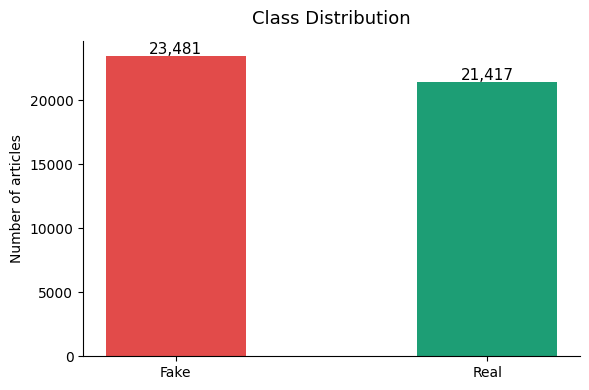

Plot saved.


In [4]:
# Create figure
fig, ax = plt.subplots(figsize=(6, 4))

labels_name = ['Fake', 'Real']
values      = [len(fake_df), len(real_df)]
colors      = ['#E24B4A', '#1D9E75']

#Draw bar chart
bars = ax.bar(labels_name, values, color=colors, width=0.45, edgecolor='none')
ax.set_title('Class Distribution', fontsize=13, pad=12)
ax.set_ylabel('Number of articles')

# Add count labels on top of bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 150,
            f'{val:,}', ha='center', fontsize=11, fontweight='500')

sns.despine()
plt.tight_layout()
plt.savefig("../outputs/plots/class_distribution.png", dpi=150)
plt.show()
print("Plot saved.")

## Combine title + text, measure length

In [5]:
# Combine title and text — this will be the model input
# fillna('') avoids errors if values are missing
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# Word count per article
df['word_count'] = df['content'].apply(lambda x: len(str(x).split()))

# Summary stats grouped by label
stats = df.groupby('label')['word_count'].describe()
stats.index = ['Fake', 'Real']
print(stats.round(0))

        count   mean    std  min    25%    50%    75%     max
Fake  23481.0  438.0  409.0  2.0  254.0  378.0  521.0  8148.0
Real  21417.0  396.0  274.0  4.0  159.0  369.0  534.0  5181.0


## Word count distribution plot

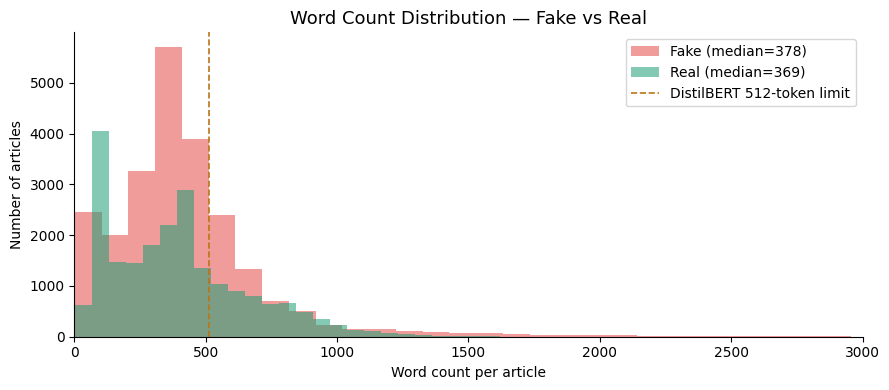

In [6]:
# Create figure
fig, ax = plt.subplots(figsize=(9, 4))

# Plot word count distributions

#Loops over:
# 0 → Fake
# 1 → Real
# Filters data for each class
# Plots histogram of word counts
# Adds median value in the legend
for label, color, name in zip([0, 1], ['#E24B4A', '#1D9E75'], ['Fake', 'Real']):
    data = df[df['label'] == label]['word_count']
    ax.hist(data, bins=80, alpha=0.55, color=color, label=f'{name} (median={int(data.median())})')

#Add model limit line - Draws a vertical line at 512 words, Shows max input size for models like DistilBERT
ax.axvline(512, color='#BA7517', linestyle='--', linewidth=1.2, label='DistilBERT 512-token limit')

ax.set_title('Word Count Distribution — Fake vs Real', fontsize=13)
ax.set_xlabel('Word count per article')
ax.set_ylabel('Number of articles')
ax.set_xlim(0, 3000)
ax.legend()

sns.despine()
plt.tight_layout()
plt.savefig("../outputs/plots/word_count_dist.png", dpi=150)
plt.show()

## Text cleaning function

In [7]:
def clean_text(text):
    text = str(text).lower()                                      # lowercase everything
    text = re.sub(r'https?://\S+|www\.\S+', '', text)            # remove URLs
    text = re.sub(r'\[.*?\]', '', text)                          # remove [tags]
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # remove punctuation
    text = re.sub(r'\w*\d\w*', '', text)                         # remove words with numbers
    text = re.sub(r'\s+', ' ', text).strip()                     # collapse whitespace
    return text

# Apply cleaning to every article
#Stores result in new column clean_content
df['clean_content'] = df['content'].apply(clean_text)

# Verify before/after
print("--- BEFORE ---")
print(df['content'].iloc[0][:300])
print("\n--- AFTER ---")
print(df['clean_content'].iloc[0][:300])

--- BEFORE ---
 BREAKING: GOP Chairman Grassley Has Had Enough, DEMANDS Trump Jr. Testimony Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour, and they refuse to acknowledge that there are problems surrounding all of this. To them, it s  fake

--- AFTER ---
breaking gop chairman grassley has had enough demands trump jr testimony donald trump s white house is in chaos and they are trying to cover it up their russia problems are mounting by the hour and they refuse to acknowledge that there are problems surrounding all of this to them it s fake news or a


## Word clouds

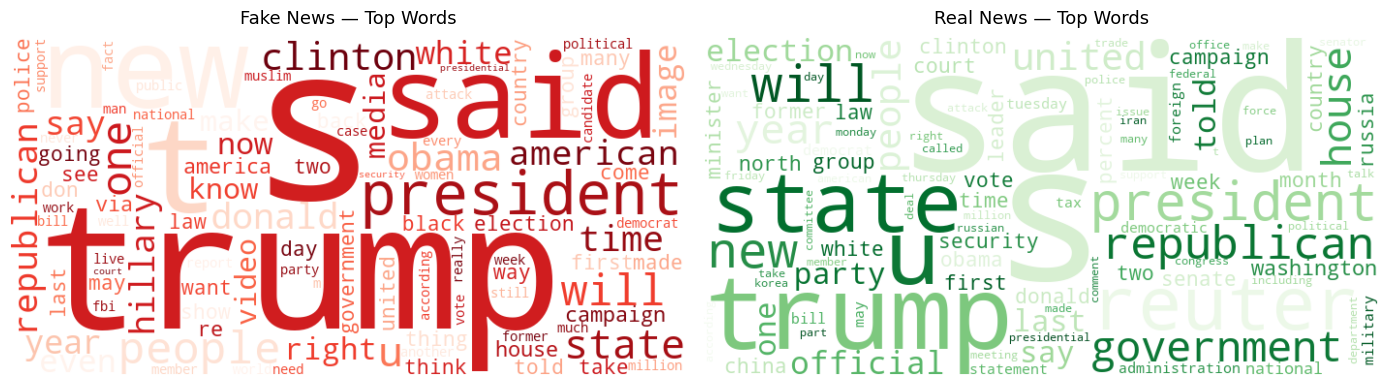

In [8]:
    # creating two word clouds:[shows the most frequent words visually bigger
    # one for Fake news
    # one for Real news

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  #Create side-by-side plots

#Loop through both classes
for ax, label, title, cmap in zip(
    axes,
    [0, 1],
    ['Fake News — Top Words', 'Real News — Top Words'],
    ['Reds', 'Greens']
):
    
# Combine all text
# Joins all articles into one big text block
# This becomes the input for the word cloud
    corpus = ' '.join(df[df['label'] == label]['clean_content'].tolist())
    wc = WordCloud(
        width=700, height=350,
        background_color='white',
        colormap=cmap,
        max_words=100,     #show top 100 words
        collocations=False       # avoids duplicate bigrams
    ).generate(corpus)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13, pad=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig("../outputs/plots/wordclouds.png", dpi=150)
plt.show()

## Save cleaned data

In [9]:
# Keep only what downstream phases need
df_final = df[['clean_content', 'label']].dropna().reset_index(drop=True)

# Save to processed folder
df_final.to_csv("../data/processed/cleaned_news.csv", index=False)

print(f"Saved {len(df_final):,} clean samples to data/processed/cleaned_news.csv")
print(f"\nFinal label distribution:")
print(df_final['label'].value_counts())

Saved 44,898 clean samples to data/processed/cleaned_news.csv

Final label distribution:
label
0    23481
1    21417
Name: count, dtype: int64
